# Book - Modern Time Series Forecasting with Python

## Chapter 10 - Building and Training LSTM Models for Time Series


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.23.5
* sklearn: 1.3.2
* seaborn: 0.13.2
* statsmodels: 0.14.1
* tensorflow: 2.12.0
* keras: 2.12.0

In [107]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')
tf.random.set_seed(42) # for reproducibility

tf.config.optimizer.set_experimental_options({
    'disable_meta_optimizer': True
})



### Data Loading

In [52]:
try:
    # Use the pre-packaged AirPassengers dataset from statsmodels
    y_series = sm.datasets.co2.load_pandas().data['co2']
    #y_series = co2.resample('W').mean().interpolate()
    y_series = y_series.resample('MS').mean().ffill()  # Monthly average
    time_idx = y_series.index
except Exception as e:
    print(f"Error loading AirPassengers dataset: {e}")


#### Visualize the Original Data

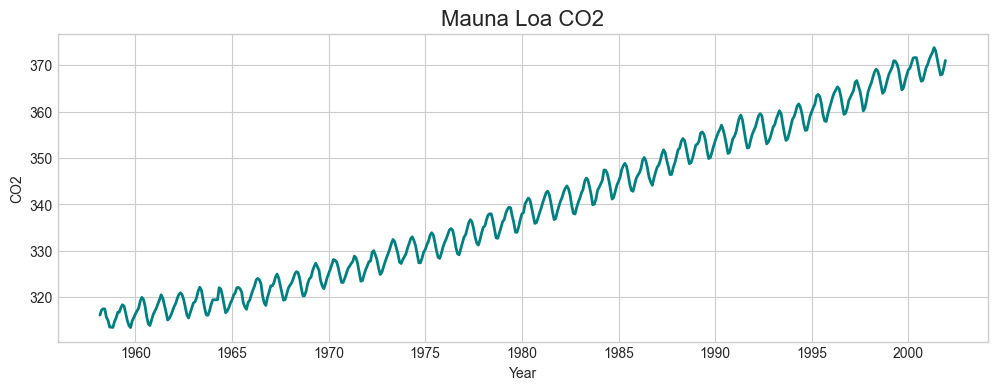

In [53]:
# Visualize the Original Data
plt.figure(figsize=(12, 4))
plt.plot(y_series, color='teal', linewidth=2)
plt.title('Mauna Loa CO2', fontsize=16)
plt.xlabel('Year')
plt.ylabel('CO2')
plt.grid(True)
plt.show()

#### Data Preparation

In [54]:
# --- Data Preparation ---
# 1. Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
# Reshape for scaler: (n_samples, n_features=1)
scaled_data = scaler.fit_transform(y_series.values.reshape(-1, 1))

# 2. Create sequences using a sliding window
n_steps_in = 12 # Use 12 past steps to predict the next step
X, y = [], []
for i in range(len(scaled_data) - n_steps_in):
    X.append(scaled_data[i:(i + n_steps_in), 0])
    y.append(scaled_data[i + n_steps_in, 0])
X, y = np.array(X), np.array(y)

# 3. Reshape X into 3D tensor for LSTM: [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))


#### Chronological Train-Test Split 

In [55]:
# --- Chronological Train-Test Split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
# Also keep original test data for final comparison
y_test_original_scale = y_series[train_size + n_steps_in:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (411, 12, 1), y_train shape: (411,)
X_test shape: (103, 12, 1), y_test shape: (103,)


In [76]:
def plot_loss(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Model Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


### <span style="color:blue">01. Build and Train the simple LSTM Model

In [56]:
# --- Build and Train the LSTM Model ---
model = Sequential([
    LSTM(units=50, activation='relu', input_shape=(n_steps_in, 1)),
    Dense(units=1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

print("\n--- Training LSTM Model ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.1, verbose=0)
print("Training complete.")


--- Training LSTM Model ---
Training complete.


#### Loss Curve (Training vs Validation)

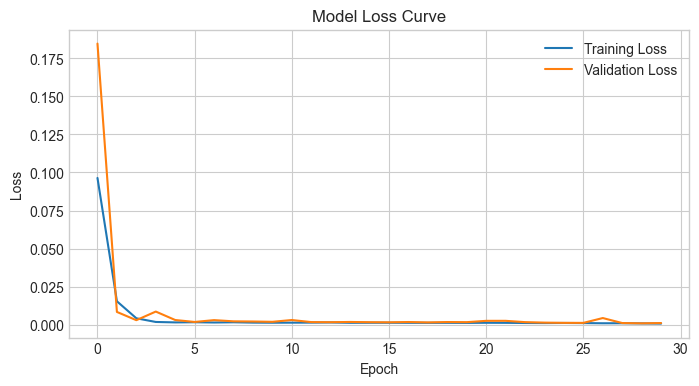

In [77]:
plot_loss(history)

#### Generate Predictions on Test Data 

In [119]:
# --- Generate Predictions on Test Data ---
print("\n--- Generating Predictions on Test Set ---")
# 1. Make predictions on the scaled test set
y_pred_scaled = model.predict(X_test)

# 2. Inverse transform the predictions to the original scale
y_pred_original_scale = scaler.inverse_transform(y_pred_scaled)
# Convert to a flat array and then a Pandas Series for easier plotting
y_pred_series = pd.Series(y_pred_original_scale.flatten(), index=y_test_original_scale.index)



--- Generating Predictions on Test Set ---
4/4 [==============================] - 0s 44ms/step


#### Evaluate Model Performance

In [120]:
# --- Evaluate Model Performance ---
print("\n--- Evaluating Model Performance ---")
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_series))
mae = mean_absolute_error(y_test_original_scale, y_pred_series)

print(f"Out-of-Sample RMSE: {rmse:.4f}")
print(f"Out-of-Sample MAE:  {mae:.4f}")




--- Evaluating Model Performance ---
Out-of-Sample RMSE: 5.0089
Out-of-Sample MAE:  4.2239


#### Visualize Forecasts vs. Actuals


--- Visualizing Forecasts vs. Actuals ---


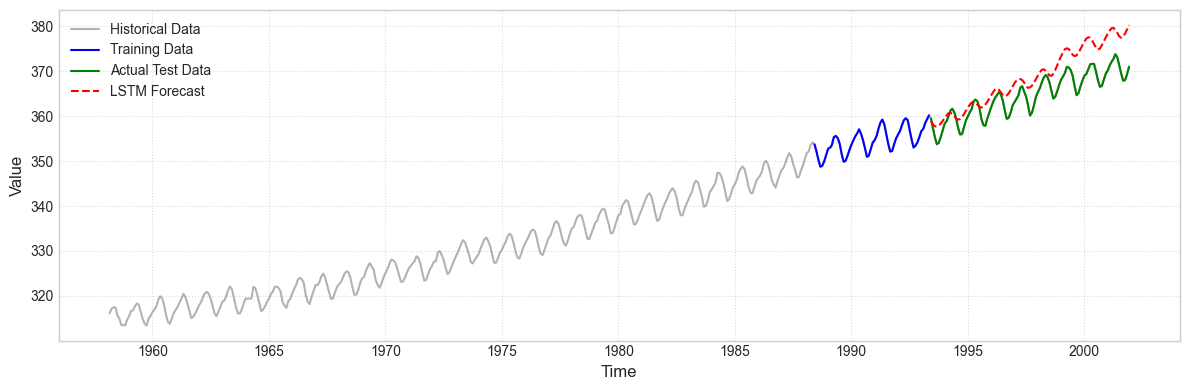

In [103]:
# --- Visualize Forecasts vs. Actuals) ---
print("\n--- Visualizing Forecasts vs. Actuals ---")
plt.figure(figsize=(12, 4))

# Plot a portion of the original series for context
plt.plot(y_series.index[-2000:], y_series.iloc[-2000:], label='Historical Data', color='gray', alpha=0.6)
# Plot training data that corresponds to the test set's start
plt.plot(y_series.index[:train_size + n_steps_in][-60:], y_series.iloc[:train_size + n_steps_in][-60:], label='Training Data', color='blue')
# Plot actual test data
plt.plot(y_test_original_scale.index, y_test_original_scale, label='Actual Test Data', color='green')
# Plot forecasted data
plt.plot(y_pred_series.index, y_pred_series, label='LSTM Forecast', color='red', linestyle='--')

plt.title('LSTM Model Performance: Forecast vs. Actuals', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Residual Analysis

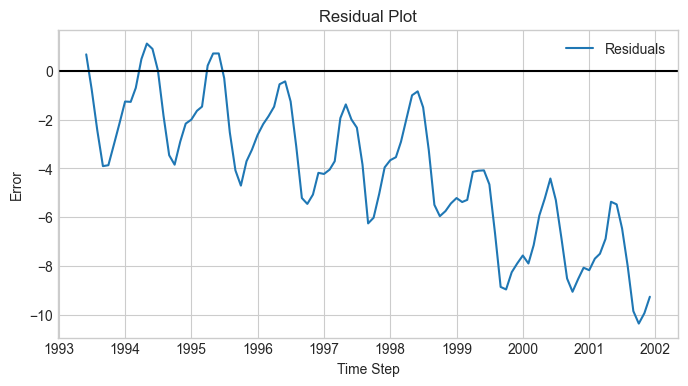

In [104]:
residuals = y_test_original_scale - y_pred_series

plt.figure(figsize=(8, 4))
plt.plot(residuals, label="Residuals")
plt.axhline(0, color='black')
plt.title("Residual Plot")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

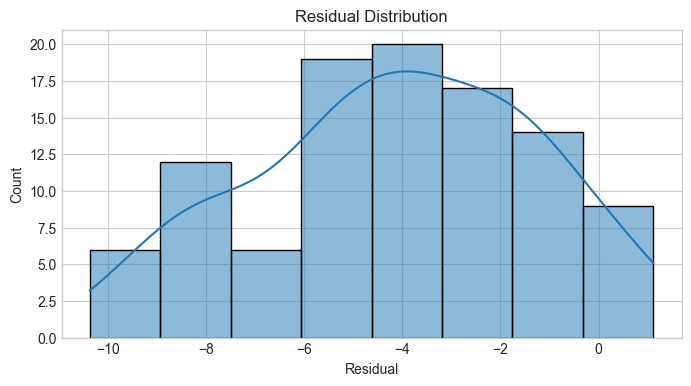

In [105]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

<Figure size 800x400 with 0 Axes>

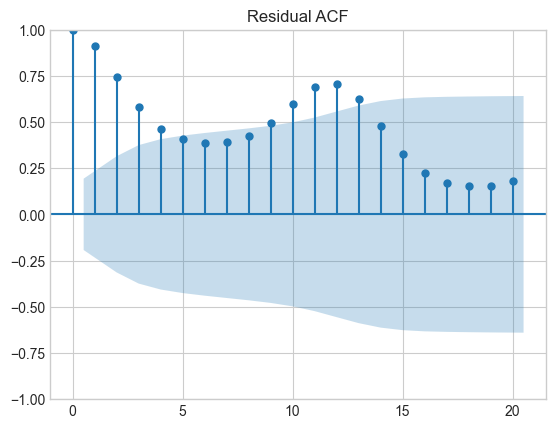

In [108]:
plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20)
plt.title("Residual ACF")
plt.grid(True)
plt.show()

### <span style="color:blue">02. Building Stacked LSTM Model

In [66]:
# --- Define model parameters for illustration ---
n_timesteps = 12  # e.g., using 12 past observations
n_features = 1    # e.g., a single univariate time series
n_outputs = 1     # e.g., predicting a single step ahead

# --- 1. Define a Stacked LSTM Model ---
stacked_lstm_model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(n_timesteps, n_features), name="LSTM_1"),
    Dropout(0.2, name="Dropout_1"), # Add Dropout for regularization (discussed in 10.5)
    LSTM(units=32, return_sequences=False, name="LSTM_2"), # Last LSTM layer
    Dropout(0.2, name="Dropout_2"),
    Dense(units=n_outputs, activation='linear', name="Output_Layer") # Linear activation for regression
], name="Stacked_LSTM_Model")

stacked_lstm_model.compile(optimizer='adam', loss='mean_squared_error')

print("\n--- Training Stacked LSTM Model ---")
stacked_history = stacked_lstm_model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.1, verbose=0)
print("Training complete.")

2025-12-07 19:02:20.149946: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-07 19:02:20.150901: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-07 19:02:20.151853: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus


--- Training LSTM Model ---


2025-12-07 19:02:20.561014: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-07 19:02:20.562135: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-07 19:02:20.563155: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Training complete.


#### Loss Curve (Training vs Validation)

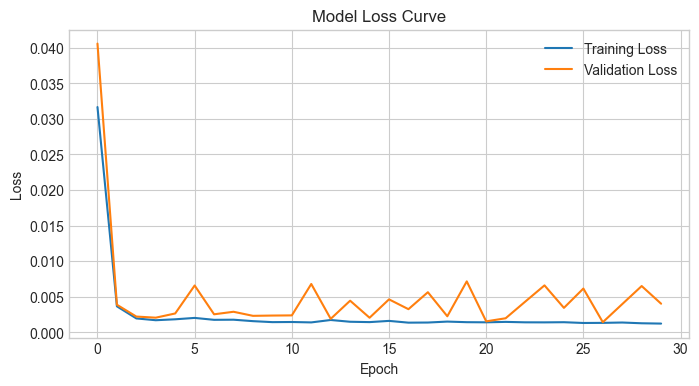

In [78]:
plot_loss(stacked_history)

#### Generate Predictions on Test Data

In [121]:
# --- Generate Predictions on Test Data ---
print("\n--- Generating Predictions on Test Set ---")
# 1. Make predictions on the scaled test set
y_pred_scaled = stacked_lstm_model.predict(X_test)

# 2. Inverse transform the predictions to the original scale
y_pred_original_scale = scaler.inverse_transform(y_pred_scaled)
# Convert to a flat array and then a Pandas Series for easier plotting
y_pred_series = pd.Series(y_pred_original_scale.flatten(), index=y_test_original_scale.index)



--- Generating Predictions on Test Set ---
4/4 [==============================] - 0s 62ms/step


#### Evaluate Model Performance

In [122]:
# --- Evaluate Model Performance ---
print("\n--- Evaluating Model Performance ---")
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_series))
mae = mean_absolute_error(y_test_original_scale, y_pred_series)

print(f"Out-of-Sample RMSE: {rmse:.4f}")
print(f"Out-of-Sample MAE:  {mae:.4f}")



--- Evaluating Model Performance ---
Out-of-Sample RMSE: 5.8105
Out-of-Sample MAE:  5.2725


#### Visualize Forecasts vs. Actuals) 


--- Visualizing Forecasts vs. Actuals ---


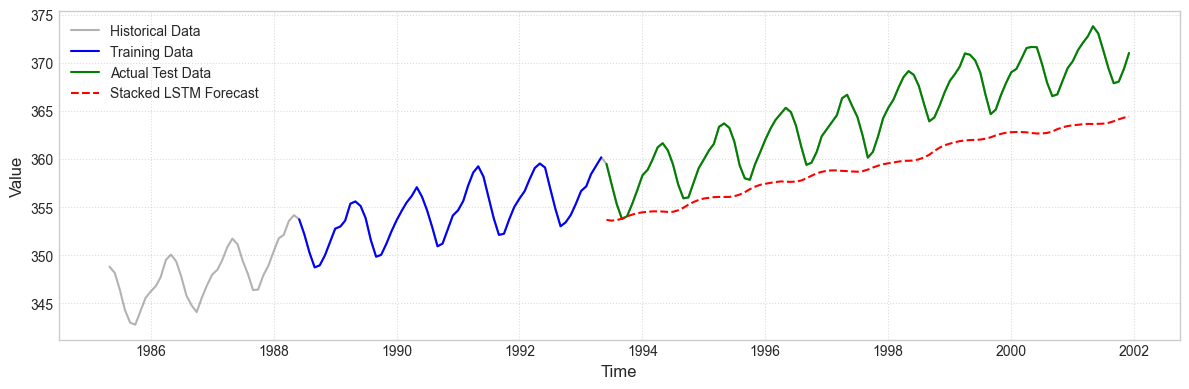

In [123]:
# --- Visualize Forecasts vs. Actuals) ---
print("\n--- Visualizing Forecasts vs. Actuals ---")
plt.figure(figsize=(12, 4))

# Plot a portion of the original series for context
plt.plot(y_series.index[-200:], y_series.iloc[-200:], label='Historical Data', color='gray', alpha=0.6)
# Plot training data that corresponds to the test set's start
plt.plot(y_series.index[:train_size + n_steps_in][-60:], y_series.iloc[:train_size + n_steps_in][-60:], label='Training Data', color='blue')
# Plot actual test data
plt.plot(y_test_original_scale.index, y_test_original_scale, label='Actual Test Data', color='green')
# Plot forecasted data
plt.plot(y_pred_series.index, y_pred_series, label='Stacked LSTM Forecast', color='red', linestyle='--')

plt.title('LSTM Model Performance: Forecast vs. Actuals', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Residual Analysis


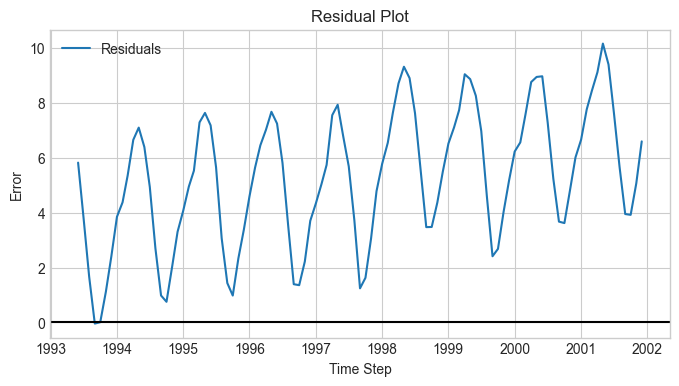

In [124]:
residuals = y_test_original_scale - y_pred_series

plt.figure(figsize=(8, 4))
plt.plot(residuals, label="Residuals")
plt.axhline(0, color='black')
plt.title("Residual Plot")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

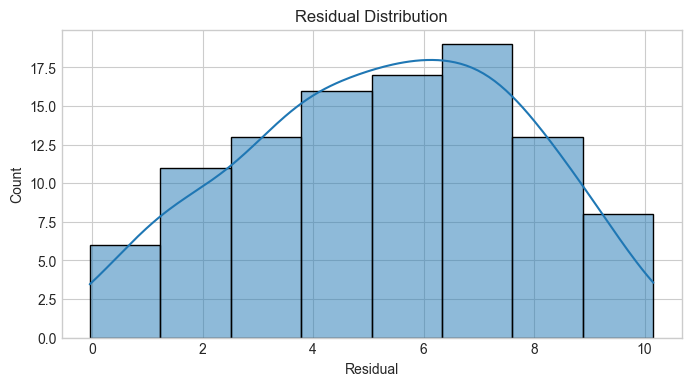

In [112]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

<Figure size 800x400 with 0 Axes>

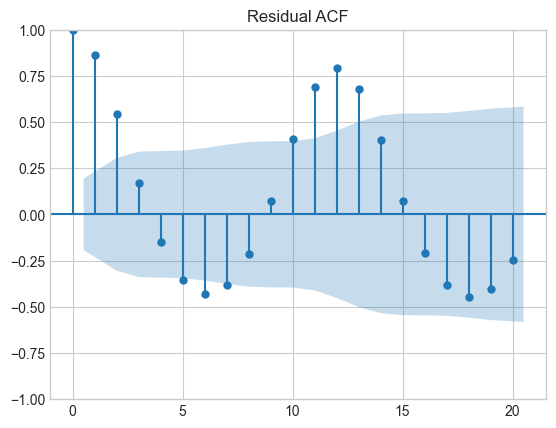

In [113]:
plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20)
plt.title("Residual ACF")
plt.grid(True)
plt.show()

### <span style="color:blue">03. Bidirectional LSTM Model 

In [73]:
bidirectional_lstm_model = Sequential([
    Bidirectional(
        LSTM(units=50, return_sequences=False),
        input_shape=(n_timesteps, n_features),
        name="Bidirectional_LSTM"
    ),
    Dense(units=n_outputs, name="Output_Layer")
], name="Bidirectional_LSTM_Model")


bidirectional_lstm_model.compile(optimizer='adam', loss='mean_squared_error')

print("\n--- Training Stacked LSTM Model ---")
bidirectional_history = bidirectional_lstm_model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.1, verbose=0)
print("Training complete.")

2025-12-07 19:23:48.495999: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-07 19:23:48.496978: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-07 19:23:48.497843: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus


--- Training Stacked LSTM Model ---


2025-12-07 19:23:48.840507: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-07 19:23:48.842142: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-07 19:23:48.843106: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Training complete.


#### Loss Curve (Training vs Validation)

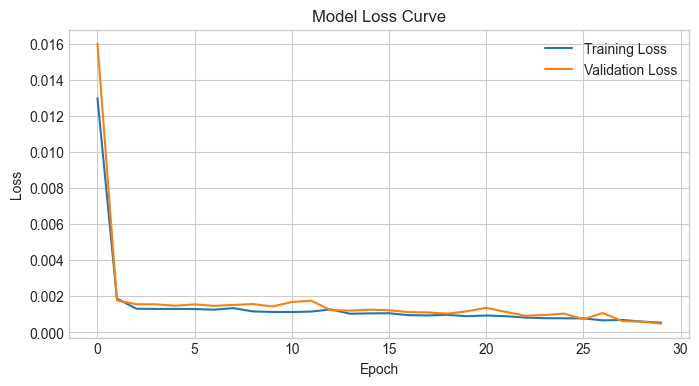

In [80]:
plot_loss(bidirectional_history)

#### Generate Predictions on Test Data

In [126]:
# --- Generate Predictions on Test Data ---
print("\n--- Generating Predictions on Test Set ---")
# 1. Make predictions on the scaled test set
y_pred_scaled = bidirectional_lstm_model.predict(X_test)

# 2. Inverse transform the predictions to the original scale
y_pred_original_scale = scaler.inverse_transform(y_pred_scaled)
# Convert to a flat array and then a Pandas Series for easier plotting
y_pred_series = pd.Series(y_pred_original_scale.flatten(), index=y_test_original_scale.index)



--- Generating Predictions on Test Set ---
4/4 [==============================] - 0s 52ms/step


#### Evaluate Model Performance

In [127]:
# --- Evaluate Model Performance ---
print("\n--- Evaluating Model Performance ---")
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_series))
mae = mean_absolute_error(y_test_original_scale, y_pred_series)

print(f"Out-of-Sample RMSE: {rmse:.4f}")
print(f"Out-of-Sample MAE:  {mae:.4f}")


--- Evaluating Model Performance ---
Out-of-Sample RMSE: 1.5138
Out-of-Sample MAE:  1.2744


#### Visualize Forecasts vs. Actuals


--- Visualizing Forecasts vs. Actuals ---


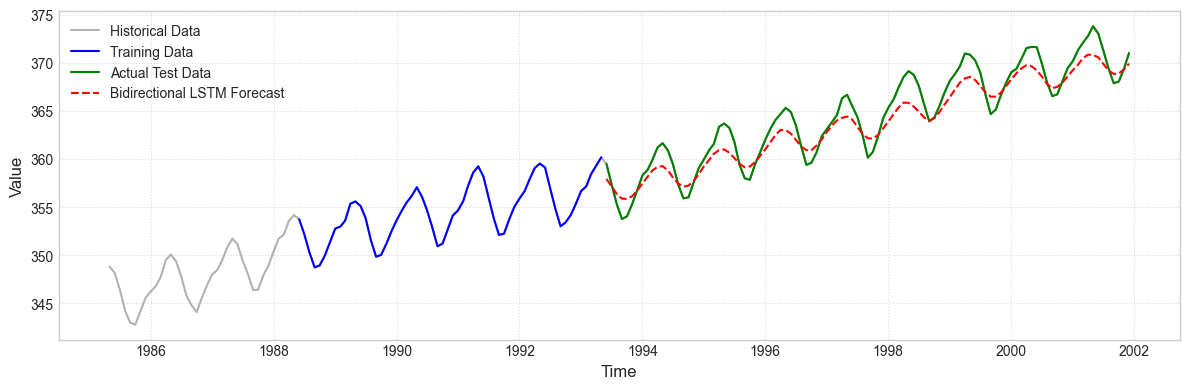

In [115]:
# --- Visualize Forecasts vs. Actuals) ---
print("\n--- Visualizing Forecasts vs. Actuals ---")
plt.figure(figsize=(12, 4))

# Plot a portion of the original series for context
plt.plot(y_series.index[-200:], y_series.iloc[-200:], label='Historical Data', color='gray', alpha=0.6)
# Plot training data that corresponds to the test set's start
plt.plot(y_series.index[:train_size + n_steps_in][-60:], y_series.iloc[:train_size + n_steps_in][-60:], label='Training Data', color='blue')
# Plot actual test data
plt.plot(y_test_original_scale.index, y_test_original_scale, label='Actual Test Data', color='green')
# Plot forecasted data
plt.plot(y_pred_series.index, y_pred_series, label='Bidirectional LSTM Forecast', color='red', linestyle='--')

plt.title('LSTM Model Performance: Forecast vs. Actuals', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Residual Analysis


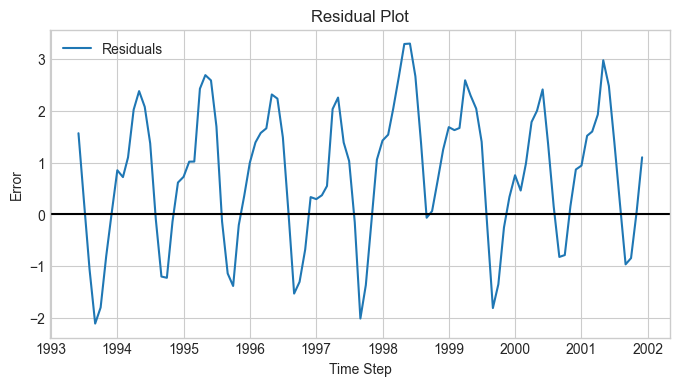

In [116]:
residuals = y_test_original_scale - y_pred_series

plt.figure(figsize=(8, 4))
plt.plot(residuals, label="Residuals")
plt.axhline(0, color='black')
plt.title("Residual Plot")
plt.xlabel("Time Step")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

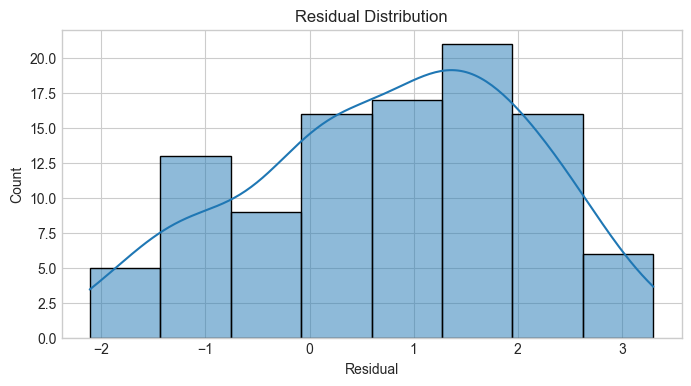

In [117]:
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

<Figure size 800x400 with 0 Axes>

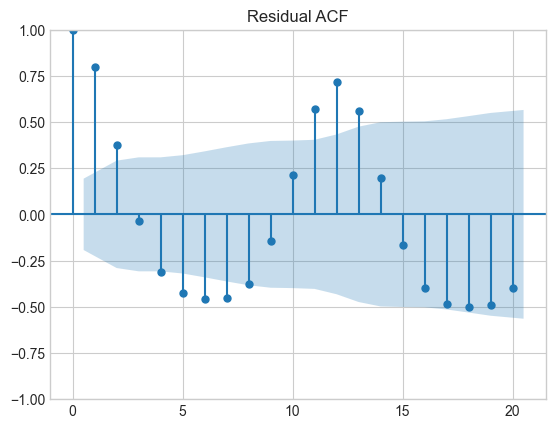

In [118]:
plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20)
plt.title("Residual ACF")
plt.grid(True)
plt.show()